<a href="https://colab.research.google.com/github/dakshini01/Statistical-Learning-e20181/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Kalman Filter Assignment




# Q1. Analytical Derivation

The filter model is

$$
x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1},
$$

$$
y_k^- = H_kx_k^- + z_k,
$$

where

$$
x_{k-1}^+ \sim \mathcal N(m_{k-1},P_{k-1}),
$$

and the noises are assumed independent:

$$
w_{k-1}\sim \mathcal N(0,\Sigma_p),
\qquad
z_k\sim \mathcal N(0,\Sigma_m).
$$

The process noise, measurement noise, and state are mutually independent.



## 1. Show that

$$
x_k^- \sim \mathcal N(m_k^-,P_k^-)
$$

where

$$
m_k^- = A_{k-1}m_{k-1}
$$

and

$$
P_k^- =
A_{k-1}P_{k-1}A_{k-1}^{T}
+
G_{k-1}\Sigma_pG_{k-1}^{T}.
$$

### Step 1 — Start from the prediction equation

$$
x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}.
$$

Both $x_{k-1}^+$ and $w_{k-1}$ are Gaussian random variables.

A linear transformation of a Gaussian random variable is also Gaussian, and the sum of independent Gaussian random variables is Gaussian.

Therefore $x_k^-$ is Gaussian.

### Step 2 — Find the predicted mean

Take expectation:

$$
E[x_k^-]
=
E[A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}].
$$

Using linearity of expectation,

$$
E[x_k^-]
=
A_{k-1}E[x_{k-1}^+]
+
G_{k-1}E[w_{k-1}].
$$

Since

$$
E[x_{k-1}^+] = m_{k-1}
$$

and

$$
E[w_{k-1}] = 0,
$$

we obtain

$$
\boxed{
m_k^- = A_{k-1}m_{k-1}
}
$$

### Step 3 — Find the predicted covariance

By definition,

$$
P_k^- = \operatorname{Var}(x_k^-).
$$

Therefore,

$$
P_k^- =
\operatorname{Var}
\left(
A_{k-1}x_{k-1}^+
+
G_{k-1}w_{k-1}
\right).
$$

Because $x_{k-1}^+$ and $w_{k-1}$ are independent,

$$
\operatorname{Var}(AX+GW)
=
A\operatorname{Var}(X)A^T
+
G\operatorname{Var}(W)G^T.
$$

Hence,

$$
\boxed{
P_k^- =
A_{k-1}P_{k-1}A_{k-1}^{T}
+
G_{k-1}\Sigma_pG_{k-1}^{T}
}
$$

and therefore

$$
\boxed{
x_k^- \sim \mathcal N(m_k^-,P_k^-)
}
$$

### Simple meaning

The Kalman filter first **moves the old estimate forward using the model**.

- $A_{k-1}m_{k-1}$ moves the old mean forward.
- $A_{k-1}P_{k-1}A_{k-1}^T$ moves the old uncertainty forward.
- $G_{k-1}\Sigma_pG_{k-1}^T$ adds uncertainty caused by process noise.



## 2. Show that

$$
y_k^- \sim
\mathcal N
\left(
H_km_k^-,
H_kP_k^-H_k^T+\Sigma_m
\right).
$$

The measurement model is

$$
y_k^- = H_kx_k^- + z_k.
$$

Since $x_k^-$ is Gaussian and $z_k$ is independent Gaussian noise, $y_k^-$ is also Gaussian.

### Mean

$$
E[y_k^-]
=
E[H_kx_k^-+z_k].
$$

Thus,

$$
E[y_k^-]
=
H_kE[x_k^-]+E[z_k].
$$

Since

$$
E[x_k^-]=m_k^-,
\qquad
E[z_k]=0,
$$

we obtain

$$
\boxed{
E[y_k^-]=H_km_k^-
}
$$

### Covariance

$$
\operatorname{Var}(y_k^-)
=
\operatorname{Var}(H_kx_k^-+z_k).
$$

Because $x_k^-$ and $z_k$ are independent,

$$
\operatorname{Var}(y_k^-)
=
H_kP_k^-H_k^T+\Sigma_m.
$$

Therefore,

$$
\boxed{
y_k^- \sim
\mathcal N
\left(
H_km_k^-,
H_kP_k^-H_k^T+\Sigma_m
\right)
}
$$

The matrix

$$
S_k = H_kP_k^-H_k^T+\Sigma_m
$$

is often called the **innovation covariance** or **measurement prediction covariance**.



## 3. Show that the joint distribution is

$$
\begin{bmatrix}
x_k^-\\
y_k^-
\end{bmatrix}
\sim
\mathcal N
\left(
\begin{bmatrix}
m_k^-\\
H_km_k^-
\end{bmatrix},
\begin{bmatrix}
P_k^- & P_k^-H_k^T\\
H_kP_k^- & H_kP_k^-H_k^T+\Sigma_m
\end{bmatrix}
\right).
$$

To construct the joint covariance, we need four blocks.

### State covariance

$$
\operatorname{Var}(x_k^-)=P_k^-.
$$

### Measurement covariance

From Question 2,

$$
\operatorname{Var}(y_k^-)
=
H_kP_k^-H_k^T+\Sigma_m.
$$

### Cross-covariance

$$
\operatorname{Cov}(x_k^-,y_k^-)
=
\operatorname{Cov}
\left(
x_k^-,
H_kx_k^-+z_k
\right).
$$

Because $z_k$ is independent of $x_k^-$,

$$
\operatorname{Cov}(x_k^-,z_k)=0.
$$

Therefore,

$$
\operatorname{Cov}(x_k^-,y_k^-)
=
\operatorname{Cov}(x_k^-,H_kx_k^-).
$$

Hence,

$$
\boxed{
\operatorname{Cov}(x_k^-,y_k^-)=P_k^-H_k^T
}
$$

and, by transpose symmetry,

$$
\boxed{
\operatorname{Cov}(y_k^-,x_k^-)=H_kP_k^-.
}
$$

Putting all the blocks together,

$$
\boxed{
\begin{bmatrix}
x_k^-\\
y_k^-
\end{bmatrix}
\sim
\mathcal N
\left(
\begin{bmatrix}
m_k^-\\
H_km_k^-
\end{bmatrix},
\begin{bmatrix}
P_k^- & P_k^-H_k^T\\
H_kP_k^- & H_kP_k^-H_k^T+\Sigma_m
\end{bmatrix}
\right)
}
$$



## 4. Show the measurement update

When the actual measurement becomes available,

$$
y_k^- = y_k^{obs}.
$$

For a jointly Gaussian random vector,

$$
\begin{bmatrix}X\\Y\end{bmatrix}
\sim
\mathcal N
\left(
\begin{bmatrix}\mu_X\\\mu_Y\end{bmatrix},
\begin{bmatrix}
\Sigma_{XX}&\Sigma_{XY}\\
\Sigma_{YX}&\Sigma_{YY}
\end{bmatrix}
\right),
$$

the conditional distribution is

$$
X\mid Y=y
\sim
\mathcal N(\mu_{X|Y},\Sigma_{X|Y}),
$$

where

$$
\mu_{X|Y}
=
\mu_X+
\Sigma_{XY}\Sigma_{YY}^{-1}(y-\mu_Y),
$$

$$
\Sigma_{X|Y}
=
\Sigma_{XX}
-
\Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}.
$$

For the Kalman filter,

$$
\mu_X=m_k^-,
$$

$$
\mu_Y=H_km_k^-,
$$

$$
\Sigma_{XX}=P_k^-,
$$

$$
\Sigma_{XY}=P_k^-H_k^T,
$$

$$
\Sigma_{YY}=H_kP_k^-H_k^T+\Sigma_m.
$$

Define the Kalman gain

$$
\boxed{
K_k
=
P_k^-H_k^T
\left(
H_kP_k^-H_k^T+\Sigma_m
\right)^{-1}
}
$$

Then the conditional mean becomes

$$
\boxed{
m_k
=
m_k^-+
K_k
\left(
y_k^{obs}-H_km_k^-
\right)
}
$$

The quantity

$$
\boxed{
y_k^{obs}-H_km_k^-
}
$$

is the **innovation** or **measurement residual**.

It tells the filter how different the actual sensor reading is from the predicted sensor reading.

For the covariance,

$$
P_k
=
P_k^-
-
P_k^-H_k^T
(H_kP_k^-H_k^T+\Sigma_m)^{-1}
H_kP_k^-.
$$

Using the definition of $K_k$,

$$
\boxed{
P_k=(I-K_kH_k)P_k^-.
}
$$

Hence,

$$
\boxed{
x_k^+
\equiv
(x_k^- \mid y_k^-=y_k^{obs})
\sim
\mathcal N(m_k,P_k)
}
$$

### Meaning of the Kalman gain

The Kalman gain decides how much the filter should trust the sensor.

- Large measurement uncertainty $\Sigma_m$ $\rightarrow$ smaller gain $\rightarrow$ trust the model more.
- Small measurement uncertainty $\Sigma_m$ $\rightarrow$ larger gain $\rightarrow$ trust the sensor more.



## 5. Find

$$
E[x_k^- \mid y_k^-=y_k^{obs}]
$$

and

$$
\operatorname{Var}(x_k^- \mid y_k^-=y_k^{obs}).
$$

From the Gaussian conditioning result derived above,

$$
\boxed{
E[x_k^- \mid y_k^-=y_k^{obs}]
=
m_k
}
$$

where

$$
\boxed{
m_k
=
m_k^-+
K_k(y_k^{obs}-H_km_k^-)
}
$$

and

$$
\boxed{
\operatorname{Var}
(x_k^- \mid y_k^-=y_k^{obs})
=
P_k
}
$$

where

$$
\boxed{
P_k=(I-K_kH_k)P_k^-.
}
$$

So the answer is simply the **posterior Kalman mean and covariance**.



# Q2. 1-D Example

Consider

$$
x_k^- = ax_{k-1}^+ + w_{k-1},
\qquad
w_{k-1}\sim\mathcal N(0,q),
$$

$$
y_k^- = hx_k^-+z_k,
\qquad
z_k\sim\mathcal N(0,r),
$$

with

$$
x_0\sim\mathcal N(m_0,P_0).
$$

Define

$$
Y_k=\{y_1^{obs},\ldots,y_k^{obs}\}.
$$

Because everything is scalar, matrices become ordinary numbers.



## 1. Prediction

Suppose

$$
x_{k-1}^+\mid Y_{k-1}
\sim
\mathcal N(m_{k-1},P_{k-1}).
$$

The model is

$$
x_k^-=ax_{k-1}^+ + w_{k-1}.
$$

### Mean

$$
m_k^-
=
E[x_k^-\mid Y_{k-1}]
$$

$$
=
aE[x_{k-1}^+\mid Y_{k-1}]
+
E[w_{k-1}].
$$

Since $E[w_{k-1}]=0$,

$$
\boxed{
m_k^-=am_{k-1}.
}
$$

### Variance

$$
P_k^-
=
\operatorname{Var}(ax_{k-1}^++w_{k-1}).
$$

Independence gives

$$
P_k^-
=
a^2P_{k-1}+q.
$$

Therefore,

$$
\boxed{
P_k^-=a^2P_{k-1}+q.
}
$$



## 2. Measurement correction

First define the predicted measurement

$$
\hat y_k^- = hm_k^-.
$$

The innovation is

$$
\boxed{
v_k=y_k^{obs}-hm_k^-.
}
$$

Its variance is

$$
\boxed{
S_k=h^2P_k^-+r.
}
$$

The scalar Kalman gain is

$$
\boxed{
K_k=\frac{P_k^-h}{S_k}
=
\frac{P_k^-h}{h^2P_k^-+r}.
}
$$

Therefore the posterior mean is

$$
\boxed{
m_k
=
m_k^-+
K_kv_k
}
$$

or

$$
\boxed{
m_k
=
m_k^-+
\frac{P_k^-h}{S_k}
(y_k^{obs}-hm_k^-).
}
$$

The posterior covariance is

$$
\boxed{
P_k
=
(1-K_kh)P_k^-.
}
$$

Substituting $K_k$,

$$
P_k
=
\left(
1-\frac{P_k^-h^2}{S_k}
\right)P_k^-.
$$

Hence,

$$
\boxed{
P_k
=
\left(
1-\frac{P_k^-h^2}{h^2P_k^-+r}
\right)P_k^-.
}
$$



## 3. Predictive measurement distribution before seeing $y_k$

Before the current observation is seen,

$$
x_k^- \mid Y_{k-1}
\sim
\mathcal N(m_k^-,P_k^-).
$$

Since

$$
y_k^-=hx_k^-+z_k,
$$

the conditional mean is

$$
E[y_k^-\mid Y_{k-1}]
=
hm_k^-.
$$

The conditional variance is

$$
\operatorname{Var}(y_k^-\mid Y_{k-1})
=
h^2P_k^-+r.
$$

Therefore,

$$
\boxed{
p(y_k^-\mid Y_{k-1})
=
\mathcal N
\left(
hm_k^-,
h^2P_k^-+r
\right).
}
$$



## 4. Posterior-predictive measurement distribution

After using $y_k^{obs}$, the posterior state is

$$
x_k^+\mid Y_k
\sim
\mathcal N(m_k,P_k).
$$

For a measurement generated from that posterior state,

$$
y=hx_k^++z,
\qquad
z\sim\mathcal N(0,r),
$$

we get

$$
E[y\mid Y_k]=hm_k
$$

and

$$
\operatorname{Var}(y\mid Y_k)=h^2P_k+r.
$$

Thus,

$$
\boxed{
p(y\mid Y_k)
=
\mathcal N
\left(
hm_k,
h^2P_k+r
\right).
}
$$

This is the expression requested in the assignment. It is naturally interpreted as the distribution of a **new/replicate measurement generated after the state has been updated using $Y_k$**.



## 5. Numerical 1-D Kalman filter and animation

The next cells use the following example values:

$$
a=1,\qquad
h=1,\qquad
q=0.04,\qquad
r=1.0.
$$

Interpretation:

- $a=1$: the state tends to continue from the previous value.
- $q=0.04$: the system itself has a small amount of uncertainty.
- $h=1$: the sensor directly measures the state.
- $r=1$: the sensor is fairly noisy.

The animation shows:

- **Prior PDF:** our belief before reading the current sensor value.
- **Posterior PDF:** our belief after using the current sensor value.
- The vertical dashed lines show the true state and current measurement.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Numerical parameters
a = 1.0
h = 1.0
q = 0.04
r = 1.0

m0 = 0.0
P0 = 4.0

T = 60
rng = np.random.default_rng(7)

# Simulate a scalar system
x_true = np.zeros(T)
y_obs = np.zeros(T)

x_true[0] = 2.0
y_obs[0] = h*x_true[0] + rng.normal(0, np.sqrt(r))

for k in range(1, T):
    x_true[k] = a*x_true[k-1] + rng.normal(0, np.sqrt(q))
    y_obs[k] = h*x_true[k] + rng.normal(0, np.sqrt(r))

# Kalman filter arrays
m_prior = np.zeros(T)
P_prior = np.zeros(T)
m_post = np.zeros(T)
P_post = np.zeros(T)
K_hist = np.zeros(T)

m_prev, P_prev = m0, P0

for k in range(T):
    # Prediction
    m_minus = a * m_prev
    P_minus = a**2 * P_prev + q

    # Measurement update
    S = h**2 * P_minus + r
    K = P_minus * h / S
    innovation = y_obs[k] - h * m_minus

    m = m_minus + K * innovation
    P = (1 - K*h) * P_minus

    m_prior[k] = m_minus
    P_prior[k] = P_minus
    m_post[k] = m
    P_post[k] = P
    K_hist[k] = K

    m_prev, P_prev = m, P

print("Final posterior mean:", m_post[-1])
print("Final posterior variance:", P_post[-1])
print("Final Kalman gain:", K_hist[-1])


Final posterior mean: 0.9787885435010245
Final posterior variance: 0.18099751243670617
Final Kalman gain: 0.18099751243670617


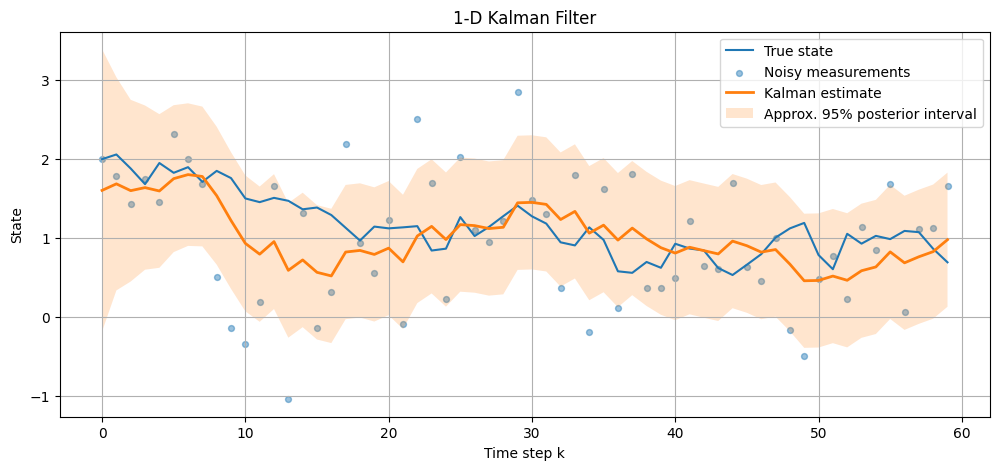

In [2]:

# Plot the complete time history
plt.figure(figsize=(12, 5))
plt.plot(x_true, label="True state")
plt.scatter(np.arange(T), y_obs, s=18, alpha=0.45, label="Noisy measurements")
plt.plot(m_post, linewidth=2, label="Kalman estimate")
plt.fill_between(
    np.arange(T),
    m_post - 2*np.sqrt(P_post),
    m_post + 2*np.sqrt(P_post),
    alpha=0.2,
    label="Approx. 95% posterior interval"
)
plt.xlabel("Time step k")
plt.ylabel("State")
plt.title("1-D Kalman Filter")
plt.grid(True)
plt.legend()
plt.show()


In [3]:

# Animation of the PRIOR and POSTERIOR Gaussian distributions.
# Run this cell in Google Colab.

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def normal_pdf(x, mean, var):
    return np.exp(-0.5*(x-mean)**2/var) / np.sqrt(2*np.pi*var)

xmin = min(
    np.min(x_true),
    np.min(y_obs),
    np.min(m_prior - 4*np.sqrt(P_prior)),
    np.min(m_post - 4*np.sqrt(P_post))
) - 1

xmax = max(
    np.max(x_true),
    np.max(y_obs),
    np.max(m_prior + 4*np.sqrt(P_prior)),
    np.max(m_post + 4*np.sqrt(P_post))
) + 1

x_grid = np.linspace(xmin, xmax, 600)

fig, ax = plt.subplots(figsize=(10, 5))

def update(frame):
    ax.clear()

    prior_pdf = normal_pdf(x_grid, m_prior[frame], P_prior[frame])
    post_pdf = normal_pdf(x_grid, m_post[frame], P_post[frame])

    ax.plot(x_grid, prior_pdf, linewidth=2, label="Prior distribution")
    ax.plot(x_grid, post_pdf, linewidth=2, label="Posterior distribution")

    ax.axvline(x_true[frame], linestyle="--", linewidth=2, label="True state")
    ax.axvline(y_obs[frame], linestyle=":", linewidth=2, label="Measurement")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0, max(np.max(prior_pdf), np.max(post_pdf))*1.25)
    ax.set_xlabel("Possible state value")
    ax.set_ylabel("Probability density")
    ax.set_title(
        f"1-D Kalman Filter, step {frame}\n"
        f"Prior: N({m_prior[frame]:.2f}, {P_prior[frame]:.2f})   "
        f"Posterior: N({m_post[frame]:.2f}, {P_post[frame]:.2f})"
    )
    ax.grid(True)
    ax.legend(loc="upper left")

anim = FuncAnimation(fig, update, frames=T, interval=250, repeat=True)
plt.close(fig)

HTML(anim.to_jshtml())



### What the animation demonstrates

At each time step:

1. The model produces a **prior distribution**.
2. A noisy measurement arrives.
3. The Kalman gain decides how strongly that measurement should influence the estimate.
4. The **posterior distribution** usually becomes narrower than the prior distribution because we now have more information.
5. That posterior becomes the starting point for the next prediction.



# Q3. 2-D Position Estimation — Part A

The hidden state is

$$
x_k=
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}.
$$

The measurement contains position only:

$$
y_k=
\begin{bmatrix}
p_x^{meas}(k)\\
p_y^{meas}(k)
\end{bmatrix}.
$$

The model is

$$
x_k^- = Ax_{k-1}^+ + Gw_{k-1},
$$

$$
y_k^- = Hx_k^- + z_k.
$$

We now derive $A$, $H$, and $G$.



## Derivation of the state-transition matrix $A$

For constant velocity over one sampling period $\Delta t$,

$$
p_x(k)
=
p_x(k-1)+\Delta t\,v_x(k-1),
$$

$$
p_y(k)
=
p_y(k-1)+\Delta t\,v_y(k-1),
$$

$$
v_x(k)=v_x(k-1),
$$

$$
v_y(k)=v_y(k-1).
$$

Write these four equations in matrix form:

$$
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1&0&\Delta t&0\\
0&1&0&\Delta t\\
0&0&1&0\\
0&0&0&1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1)\\
p_y(k-1)\\
v_x(k-1)\\
v_y(k-1)
\end{bmatrix}.
$$

Therefore,

$$
\boxed{
A=
\begin{bmatrix}
1&0&\Delta t&0\\
0&1&0&\Delta t\\
0&0&1&0\\
0&0&0&1
\end{bmatrix}.
}
$$



## Derivation of the measurement matrix $H$

GPS measures only position.

Therefore,

$$
p_x^{meas}=p_x+\text{noise}
$$

and

$$
p_y^{meas}=p_y+\text{noise}.
$$

The velocity components do not appear directly in the measurement.

Thus,

$$
\begin{bmatrix}
p_x^{meas}\\
p_y^{meas}
\end{bmatrix}
=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0
\end{bmatrix}
\begin{bmatrix}
p_x\\
p_y\\
v_x\\
v_y
\end{bmatrix}
+
z_k.
$$

Hence,

$$
\boxed{
H=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0
\end{bmatrix}.
}
$$



## Derivation of the process-noise matrix $G$

The constant-velocity model is not perfect because the real object can accelerate.

Let the unknown acceleration during one time step be

$$
w_{k-1}
=
\begin{bmatrix}
a_x(k-1)\\
a_y(k-1)
\end{bmatrix}.
$$

From basic kinematics,

$$
p_x(k)
=
p_x(k-1)
+
\Delta t\,v_x(k-1)
+
\frac12\Delta t^2a_x(k-1),
$$

$$
p_y(k)
=
p_y(k-1)
+
\Delta t\,v_y(k-1)
+
\frac12\Delta t^2a_y(k-1),
$$

$$
v_x(k)
=
v_x(k-1)+\Delta t\,a_x(k-1),
$$

$$
v_y(k)
=
v_y(k-1)+\Delta t\,a_y(k-1).
$$

Therefore the acceleration enters the state through

$$
G
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}
=
\begin{bmatrix}
\frac12\Delta t^2a_x\\
\frac12\Delta t^2a_y\\
\Delta t\,a_x\\
\Delta t\,a_y
\end{bmatrix}.
$$

Hence,

$$
\boxed{
G=
\begin{bmatrix}
\frac12\Delta t^2&0\\
0&\frac12\Delta t^2\\
\Delta t&0\\
0&\Delta t
\end{bmatrix}.
}
$$

So the required matrices are

$$
\boxed{
A=
\begin{bmatrix}
1&0&\Delta t&0\\
0&1&0&\Delta t\\
0&0&1&0\\
0&0&0&1
\end{bmatrix},
\quad
H=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0
\end{bmatrix},
\quad
G=
\begin{bmatrix}
\frac12\Delta t^2&0\\
0&\frac12\Delta t^2\\
\Delta t&0\\
0&\Delta t
\end{bmatrix}.
}
$$



# Q3. 2-D Position Estimation — Part B

## Python method to filter noisy GPS position measurements

The state is

$$
x_k=
[p_x,\;p_y,\;v_x,\;v_y]^T.
$$

At every sample, the algorithm performs:

### Prediction

$$
m_k^- = Am_{k-1},
$$

$$
P_k^- = AP_{k-1}A^T+G\Sigma_pG^T.
$$

### Measurement prediction

$$
\hat y_k=Hm_k^-.
$$

### Innovation

$$
r_k=y_k^{GPS}-\hat y_k.
$$

### Innovation covariance

$$
S_k=HP_k^-H^T+\Sigma_m.
$$

### Kalman gain

$$
K_k=P_k^-H^TS_k^{-1}.
$$

### Correction

$$
m_k=m_k^-+K_kr_k.
$$

$$
P_k=(I-K_kH)P_k^-.
$$

The function below accepts any sequence of GPS measurements with shape `(N, 2)`.


In [4]:

import numpy as np

def kalman_filter_gps_2d(
    gps_xy,
    dt=1.0,
    sigma_acc=0.5,
    sigma_gps=3.0,
    x0=None,
    P0=None
):
    """
    Filter 2-D GPS position measurements using a constant-velocity Kalman filter.

    Parameters
    ----------
    gps_xy : array-like, shape (N, 2)
        GPS measurements [x, y].
    dt : float
        Sampling interval.
    sigma_acc : float
        Standard deviation of unknown acceleration.
    sigma_gps : float
        Standard deviation of GPS position noise in each axis.
    x0 : array-like, shape (4,), optional
        Initial [px, py, vx, vy].
    P0 : ndarray, shape (4,4), optional
        Initial state covariance.

    Returns
    -------
    estimates : ndarray, shape (N,4)
        Posterior state estimates [px, py, vx, vy].
    covariances : ndarray, shape (N,4,4)
        Posterior covariance matrices.
    predicted_measurements : ndarray, shape (N,2)
        Predicted GPS measurements before correction.
    """
    gps_xy = np.asarray(gps_xy, dtype=float)

    if gps_xy.ndim != 2 or gps_xy.shape[1] != 2:
        raise ValueError("gps_xy must have shape (N, 2)")

    # State-transition matrix
    A = np.array([
        [1.0, 0.0, dt,  0.0],
        [0.0, 1.0, 0.0, dt ],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0]
    ])

    # GPS measures position only
    H = np.array([
        [1.0, 0.0, 0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0]
    ])

    # Unknown acceleration enters position and velocity
    G = np.array([
        [0.5*dt**2, 0.0],
        [0.0, 0.5*dt**2],
        [dt, 0.0],
        [0.0, dt]
    ])

    # Acceleration-noise covariance
    Sigma_p = sigma_acc**2 * np.eye(2)

    # GPS measurement-noise covariance
    Sigma_m = sigma_gps**2 * np.eye(2)

    # State-space process covariance
    Q = G @ Sigma_p @ G.T

    # Initial state
    if x0 is None:
        if len(gps_xy) >= 2:
            vx0 = (gps_xy[1, 0] - gps_xy[0, 0]) / dt
            vy0 = (gps_xy[1, 1] - gps_xy[0, 1]) / dt
        else:
            vx0 = 0.0
            vy0 = 0.0

        x = np.array([gps_xy[0, 0], gps_xy[0, 1], vx0, vy0], dtype=float)
    else:
        x = np.asarray(x0, dtype=float).reshape(4)

    if P0 is None:
        P = np.diag([
            sigma_gps**2,
            sigma_gps**2,
            25.0,
            25.0
        ])
    else:
        P = np.asarray(P0, dtype=float).reshape(4, 4)

    I = np.eye(4)

    estimates = np.zeros((len(gps_xy), 4))
    covariances = np.zeros((len(gps_xy), 4, 4))
    predicted_measurements = np.zeros((len(gps_xy), 2))

    for k, y in enumerate(gps_xy):
        # ------------------
        # 1. PREDICTION
        # ------------------
        x_minus = A @ x
        P_minus = A @ P @ A.T + Q

        # ------------------
        # 2. PREDICT SENSOR
        # ------------------
        y_hat = H @ x_minus

        # ------------------
        # 3. INNOVATION
        # ------------------
        innovation = y - y_hat

        # ------------------
        # 4. INNOVATION COVARIANCE
        # ------------------
        S = H @ P_minus @ H.T + Sigma_m

        # ------------------
        # 5. KALMAN GAIN
        # ------------------
        # Numerically better than explicitly computing inv(S)
        K = np.linalg.solve(S, H @ P_minus).T

        # ------------------
        # 6. CORRECTION
        # ------------------
        x = x_minus + K @ innovation

        # Joseph form for better numerical stability
        IKH = I - K @ H
        P = IKH @ P_minus @ IKH.T + K @ Sigma_m @ K.T

        estimates[k] = x
        covariances[k] = P
        predicted_measurements[k] = y_hat

    return estimates, covariances, predicted_measurements



## Demonstration using simulated noisy GPS

The following cell creates a moving object, corrupts its true position with GPS noise, and then filters the measurements.

This lets us verify that the algorithm works before using real GPS data.


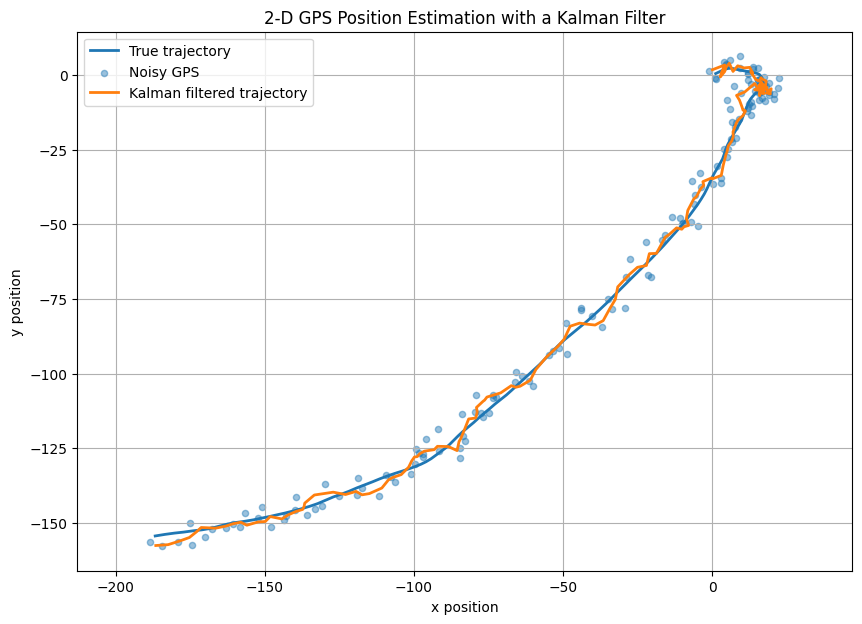

In [5]:

import matplotlib.pyplot as plt

rng = np.random.default_rng(10)

# Simulation setup
N = 150
dt = 1.0

# True state: [px, py, vx, vy]
true_state = np.array([0.0, 0.0, 1.2, 0.6])

true_states = np.zeros((N, 4))
gps_measurements = np.zeros((N, 2))

sigma_acc_true = 0.15
sigma_gps_true = 3.0

for k in range(N):
    # Small random acceleration
    ax, ay = rng.normal(0.0, sigma_acc_true, size=2)

    # Propagate true motion
    true_state[0] += true_state[2]*dt + 0.5*ax*dt**2
    true_state[1] += true_state[3]*dt + 0.5*ay*dt**2
    true_state[2] += ax*dt
    true_state[3] += ay*dt

    true_states[k] = true_state

    # GPS observes position with noise
    gps_measurements[k] = true_state[:2] + rng.normal(
        0.0, sigma_gps_true, size=2
    )

estimates, covariances, yhat = kalman_filter_gps_2d(
    gps_measurements,
    dt=dt,
    sigma_acc=0.3,
    sigma_gps=sigma_gps_true
)

plt.figure(figsize=(10, 7))
plt.plot(
    true_states[:, 0],
    true_states[:, 1],
    linewidth=2,
    label="True trajectory"
)
plt.scatter(
    gps_measurements[:, 0],
    gps_measurements[:, 1],
    s=20,
    alpha=0.45,
    label="Noisy GPS"
)
plt.plot(
    estimates[:, 0],
    estimates[:, 1],
    linewidth=2,
    label="Kalman filtered trajectory"
)

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("2-D GPS Position Estimation with a Kalman Filter")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


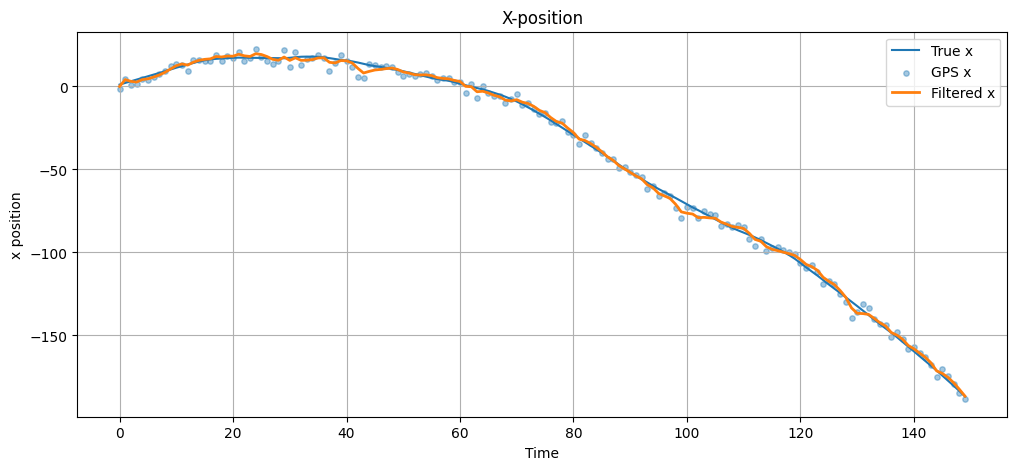

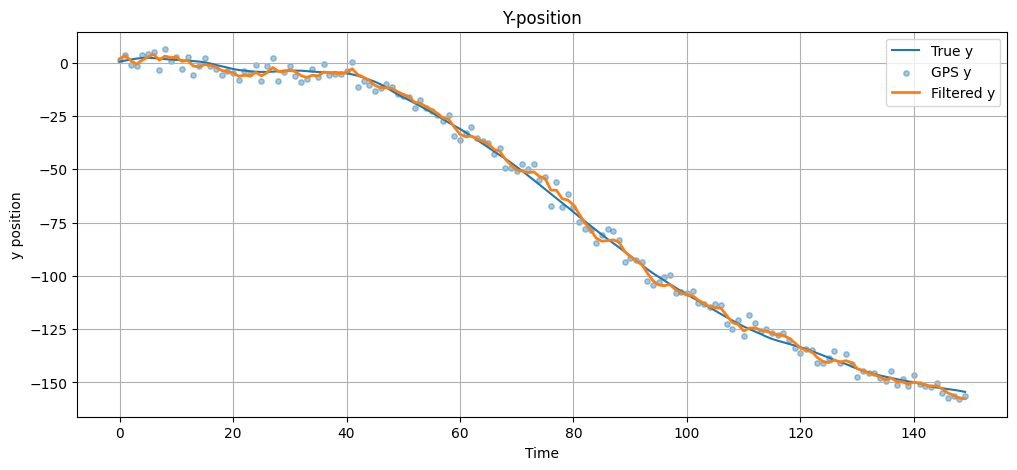

In [6]:

# Compare x-position and y-position over time
t = np.arange(N) * dt

plt.figure(figsize=(12, 5))
plt.plot(t, true_states[:, 0], label="True x")
plt.scatter(t, gps_measurements[:, 0], s=15, alpha=0.4, label="GPS x")
plt.plot(t, estimates[:, 0], linewidth=2, label="Filtered x")
plt.xlabel("Time")
plt.ylabel("x position")
plt.title("X-position")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, true_states[:, 1], label="True y")
plt.scatter(t, gps_measurements[:, 1], s=15, alpha=0.4, label="GPS y")
plt.plot(t, estimates[:, 1], linewidth=2, label="Filtered y")
plt.xlabel("Time")
plt.ylabel("y position")
plt.title("Y-position")
plt.grid(True)
plt.legend()
plt.show()



## Using the filter with your own GPS data

If you already have a NumPy array

```python
gps_xy
```

with shape

```text
(N, 2)
```

where column 0 is x-position and column 1 is y-position, use:

```python
estimates, covariances, yhat = kalman_filter_gps_2d(
    gps_xy,
    dt=1.0,
    sigma_acc=0.5,
    sigma_gps=3.0
)

filtered_xy = estimates[:, :2]
```

The first two columns of `estimates` are the filtered position:

$$
[\hat p_x,\hat p_y].
$$

The last two columns are the estimated velocity:

$$
[\hat v_x,\hat v_y].
$$
